In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import boxplot
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

In [7]:
df=pd.read_csv("cardio_train.xls", sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [8]:
df.shape

(70000, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [10]:
df.drop(['id'],axis=1,inplace=True)

In [11]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
df.value_counts()

age    gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  active  cardio
22077  1       175     69.0    120    80     1            1     0      0     1       1         2
16805  1       157     67.0    120    80     1            1     0      0     1       0         2
20516  1       164     66.0    120    80     1            1     0      0     0       0         2
21119  1       160     60.0    120    80     1            1     0      0     0       1         2
17493  2       169     74.0    120    80     1            1     0      0     1       1         2
                                                                                              ..
18367  2       177     120.0   170    90     3            1     0      0     1       1         1
18368  1       150     50.0    140    90     3            1     0      0     1       0         1
               152     45.0    90     60     1            1     0      0     0       0         1
               156     80.0    130 

**Convert "age" from Days To Years**

In [13]:
df['age_with_years']=df['age']//365
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_with_years
0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48
4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0,52
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1,61
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1,52
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61


In [14]:
df['age_with_years'].describe().round()

count    70000.0
mean        53.0
std          7.0
min         29.0
25%         48.0
50%         53.0
75%         58.0
max         64.0
Name: age_with_years, dtype: float64

In [15]:
df.drop(['age'],axis=1,inplace= True)

<Axes: >

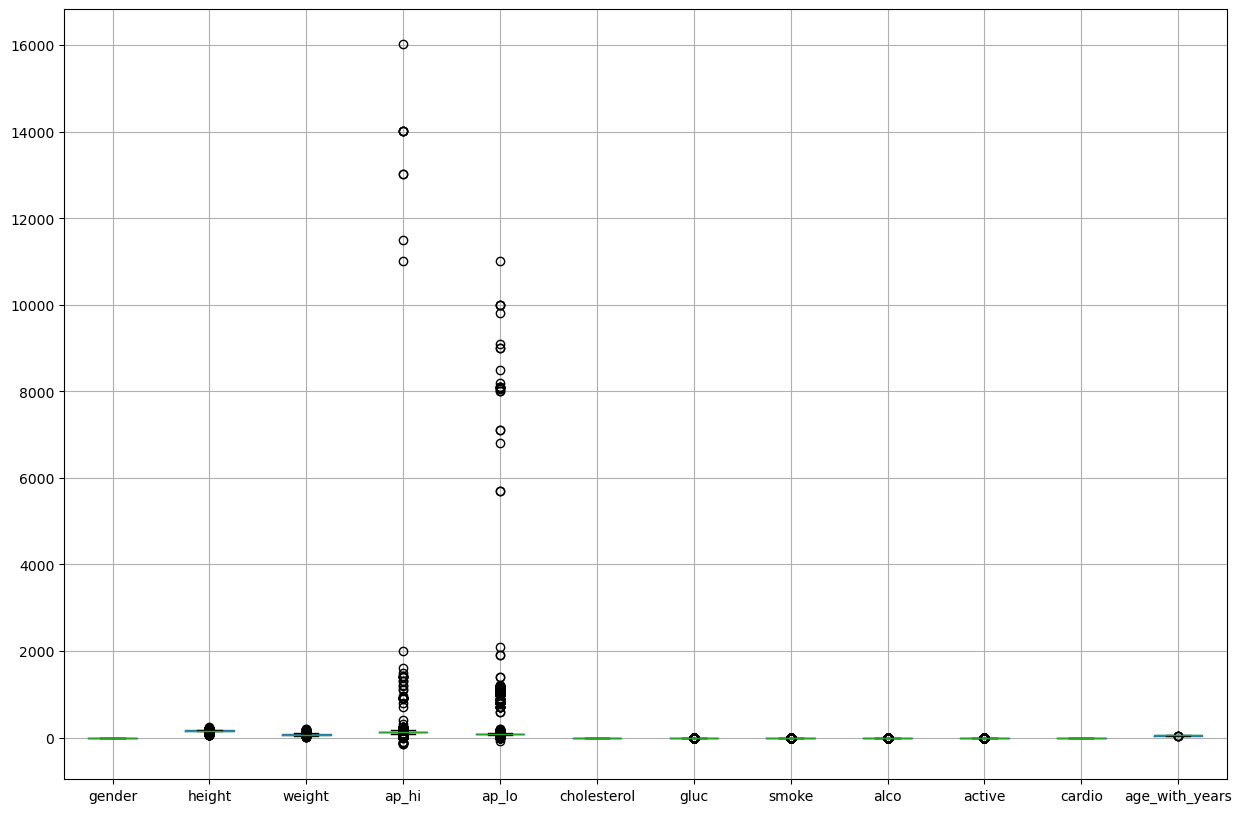

In [16]:
df.boxplot(figsize=(15,10))

featuer engineering


In [17]:
df['bmi'] = df['weight'] / ((df['height']/100) ** 2)

In [18]:
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=[0, 1, 2, 3]  # underweight, normal, overweight, obese
)

In [19]:
def bmi_risk(bmi):
    if bmi < 18.5:
        return 1
    elif bmi < 25:
        return 0
    elif bmi < 30:
        return 2
    else:
        return 3

df['bmi_risk'] = df['bmi'].apply(bmi_risk)

In [20]:
df['bmi_age'] = df['bmi'] * df['age_with_years']

In [21]:
df['bmi_bp'] = df['bmi'] * df['ap_hi']

In [22]:
df = df[(df['bmi'] > 10) & (df['bmi'] < 60)]

## **Handling Outlier** in ( ap_hi & ap_lo)

In [23]:

boxplot( df[['ap_hi','ap_lo']])

<Axes: >

In [24]:
print( " Count rows ap_hi > 250  is | ", (df['ap_hi'] > 250).sum()  )
print( " Count rows ap_lo > 200  is | ", (df['ap_lo'] > 200).sum()  )
print( " Count rows ap_lo > ap_hi  is | ", (df['ap_lo'] > df['ap_hi']).sum()  )

 Count rows ap_hi > 250  is |  40
 Count rows ap_lo > 200  is |  949
 Count rows ap_lo > ap_hi  is |  1229


In [25]:
mask = (
    (df['ap_hi'] > 250) |
    (df['ap_lo'] > 200) |
    (df['ap_hi'] < 50)  |
    (df['ap_lo'] < 30)  |
    (df['ap_lo'] >= df['ap_hi'])
)

df.drop(df[mask].index, inplace=True)

print(f" after deleting : {df.shape}")

 after deleting : (68611, 17)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19088\2968999494.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(df[mask].index, inplace=True)


In [26]:
print( " Count rows ap_hi > 250  is | ", (df['ap_hi'] > 250).sum()  )
print( " Count rows ap_lo > 200  is | ", (df['ap_lo'] > 200).sum()  )
print( " Count rows ap_lo > ap_hi  is | ", (df['ap_lo'] > df['ap_hi']).sum()  )

 Count rows ap_hi > 250  is |  0
 Count rows ap_lo > 200  is |  0
 Count rows ap_lo > ap_hi  is |  0


## **Handling Outlier** in ( height & weight)

In [27]:
mask = (
    (df['weight'] < 50) |
    (df['weight'] > 120) |
    (df['height'] > 200) |
    (df['height'] < 145)

)

df.drop(df[mask].index, inplace=True)
df.shape

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19088\1756547085.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(df[mask].index, inplace=True)


(66929, 17)

In [28]:
df.describe()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_with_years,bmi,bmi_risk,bmi_age,bmi_bp
count,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000
mean,1.352508,164.623855,74.140617,126.732313,81.344738,1.364013,1.224731,0.088332,0.053519,0.803224,0.496003,52.847495,27.406205,1.512752,1451.948002,3493.811967
std,0.477755,7.640263,13.072714,16.560548,9.392196,0.678802,0.570811,0.283780,0.225069,0.397564,0.499988,6.754991,4.836191,1.228067,333.731885,874.553340
min,1.000000,145.000000,50.000000,60.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000,14.577259,0.000000,558.693878,1421.875000
25%,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,23.875115,0.000000,1216.528926,2865.013774
50%,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.000000,26.370238,2.000000,1410.612245,3305.785124
75%,2.000000,170.000000,82.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,30.110279,3.000000,1644.881093,3954.840454
max,2.000000,198.000000,120.000000,240.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000,56.295740,3.000000,3602.927378,10379.155125


In [29]:
boxplot(df[['weight','height']],figsize=(10,10))

<Axes: >

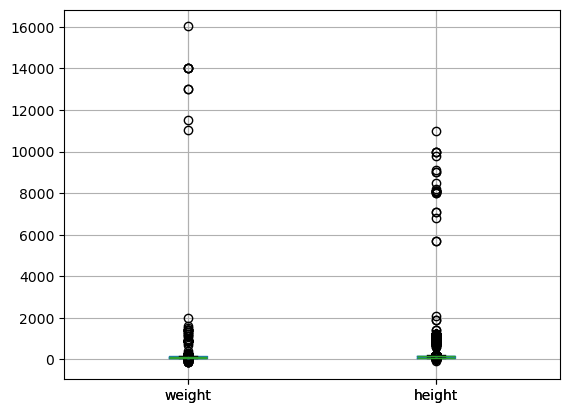

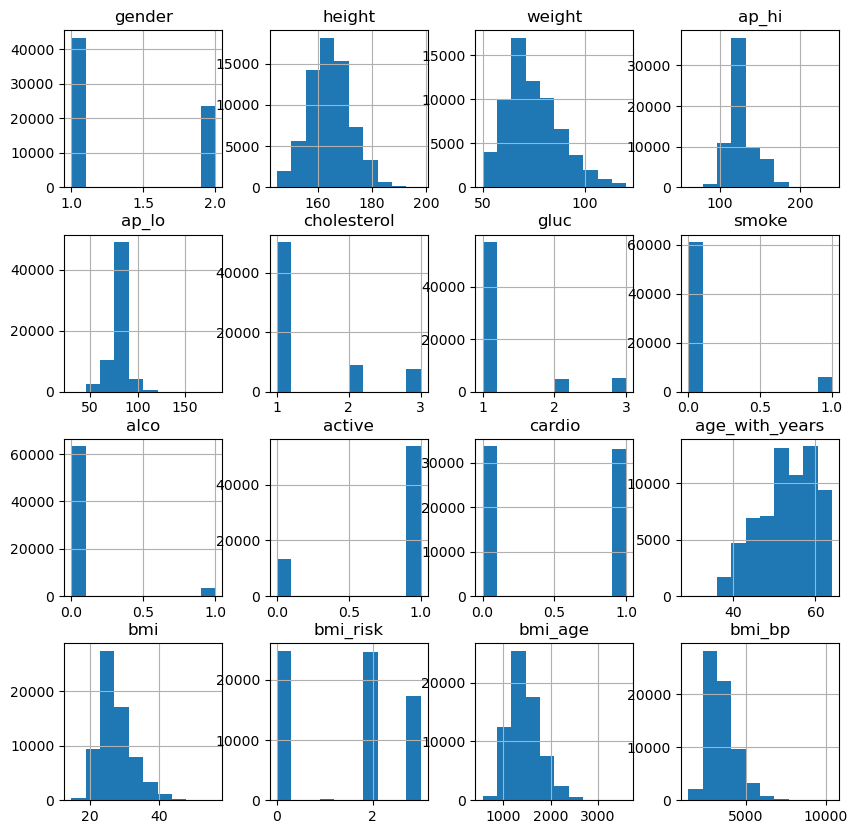

In [30]:
df.hist(figsize=(10,10))
plt.show()

In [31]:
#df['gender']= [1 if i== 2 else 0 for i in df['gender']]
df['gender'] = df['gender'].map({1: 0, 2: 1})

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19088\1334447821.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gender'] = df['gender'].map({1: 0, 2: 1})


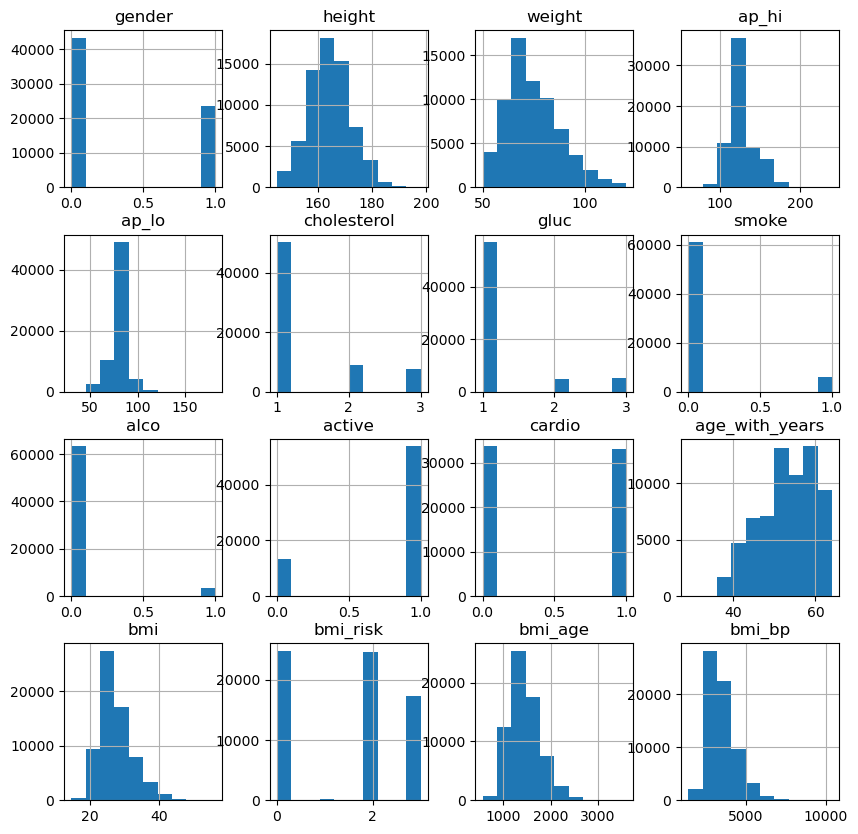

In [32]:
df.hist(figsize=(10,10))
plt.show()

In [33]:
features_to_scale = ['age_with_years', 'height', 'weight']
scaler = RobustScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
df.describe()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19088\20304759.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[features_to_scale] = scaler.fit_transform(df[features_to_scale])


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_with_years,bmi,bmi_risk,bmi_age,bmi_bp
count,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000
mean,0.352508,-0.034195,0.125919,126.732313,81.344738,1.364013,1.224731,0.088332,0.053519,0.803224,0.496003,-0.015250,27.406205,1.512752,1451.948002,3493.811967
std,0.477755,0.694569,0.768983,16.560548,9.392196,0.678802,0.570811,0.283780,0.225069,0.397564,0.499988,0.675499,4.836191,1.228067,333.731885,874.553340
min,0.000000,-1.818182,-1.294118,60.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-2.400000,14.577259,0.000000,558.693878,1421.875000
25%,0.000000,-0.545455,-0.411765,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-0.500000,23.875115,0.000000,1216.528926,2865.013774
50%,0.000000,0.000000,0.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,26.370238,2.000000,1410.612245,3305.785124
75%,1.000000,0.454545,0.588235,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.500000,30.110279,3.000000,1644.881093,3954.840454
max,1.000000,3.000000,2.823529,240.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.100000,56.295740,3.000000,3602.927378,10379.155125


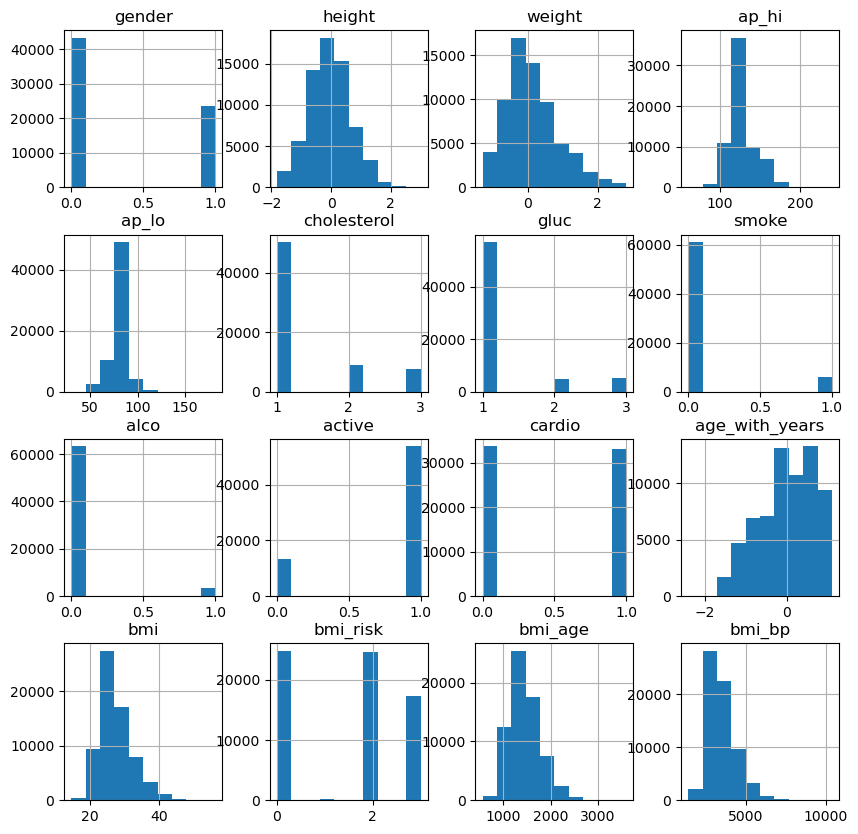

In [34]:
df.hist(figsize=(10,10))
plt.show()

In [35]:
corr = df.corr()
corr['cardio'].sort_values(ascending=False)

cardio            1.000000
ap_hi             0.425638
bmi_bp            0.353973
ap_lo             0.336119
bmi_age           0.272121
age_with_years    0.239001
cholesterol       0.220511
bmi               0.186169
bmi_category      0.175737
weight            0.173630
bmi_risk          0.170049
gluc              0.088299
gender            0.003740
alco             -0.009651
smoke            -0.017204
height           -0.020574
active           -0.037180
Name: cardio, dtype: float64

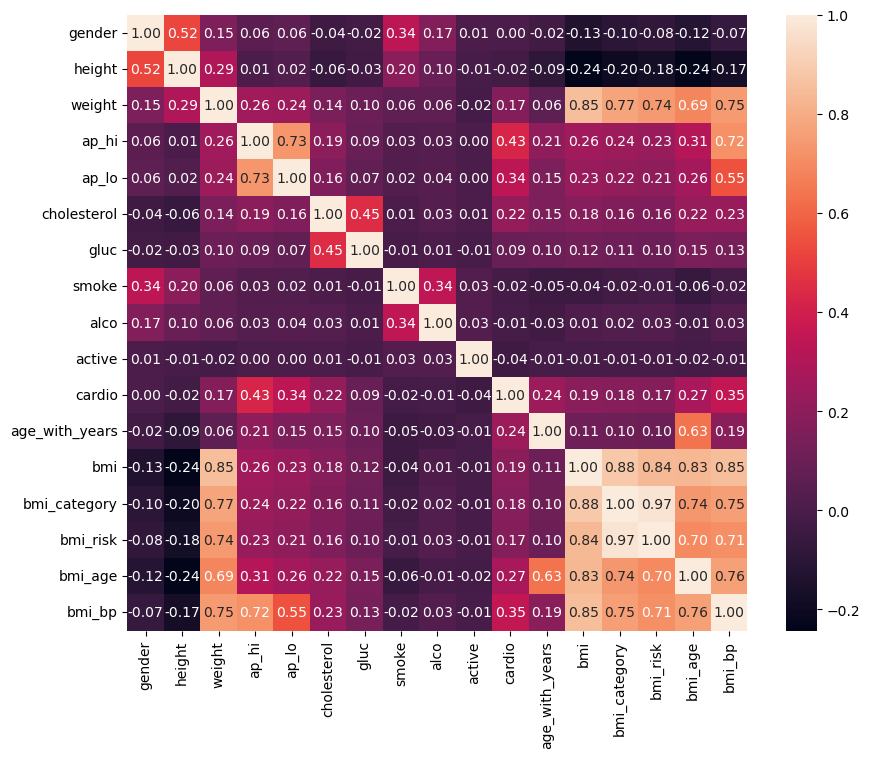

In [36]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.show()

In [37]:
important_features = ['ap_hi', 'ap_lo', 'age_with_years', 'cholesterol', 'weight','cardio']
corr = df[important_features].corr()
corr['cardio'].sort_values(ascending=False)

cardio            1.000000
ap_hi             0.425638
ap_lo             0.336119
age_with_years    0.239001
cholesterol       0.220511
weight            0.173630
Name: cardio, dtype: float64

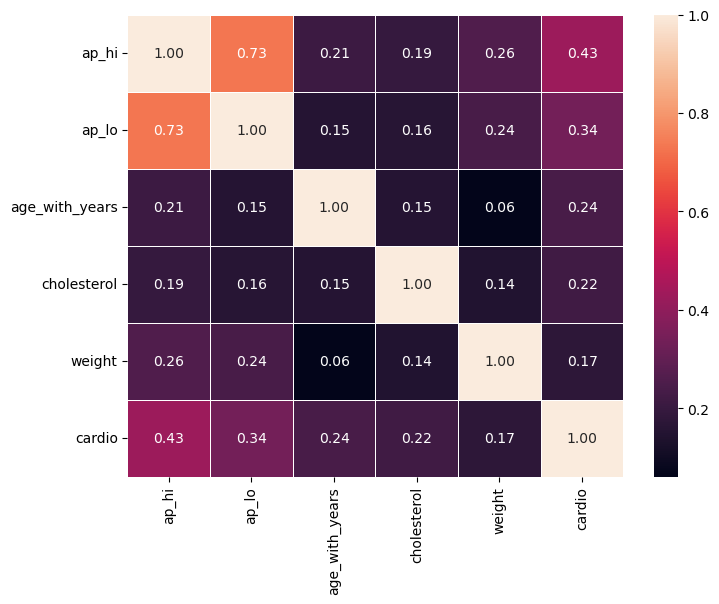

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f",linewidths=0.5)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19088\1243454387.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bp_category'] = df.apply(bp_category, axis=1)


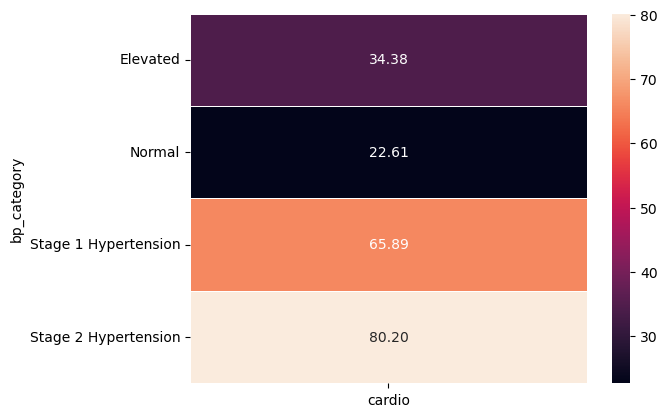

In [39]:
def bp_category(row):
    if row['ap_hi'] < 120 and row['ap_lo'] < 80:
        return 'Normal'
    elif row['ap_hi'] < 130 and row['ap_lo'] < 85:
        return 'Elevated'
    elif (130 <= row['ap_hi'] <= 139) or (80 <= row['ap_lo'] <= 89):
        return 'Stage 1 Hypertension'
    elif row['ap_hi'] >= 140 or row['ap_lo'] >= 90:
        return 'Stage 2 Hypertension'
    else:
        return 'Other'

df['bp_category'] = df.apply(bp_category, axis=1)
# حساب النسب والعدد
bp_prevalence = df.groupby('bp_category')['cardio'].mean() * 100
bp_count = df.groupby('bp_category').size()

sns.heatmap(bp_prevalence.to_frame(), annot=True, fmt=".2f",linewidths=0.5)

plt.show()

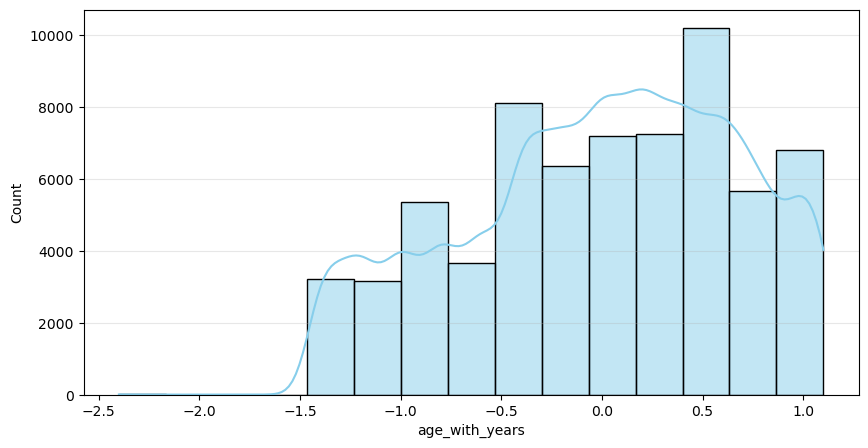

In [40]:
plt.figure(figsize=(10, 5))
sns.histplot(df['age_with_years'], bins=15, kde=True, color='skyblue')
plt.grid(axis='y', alpha=0.3)
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19088\2236454881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_years'] = df['age_with_years'] / 365.25


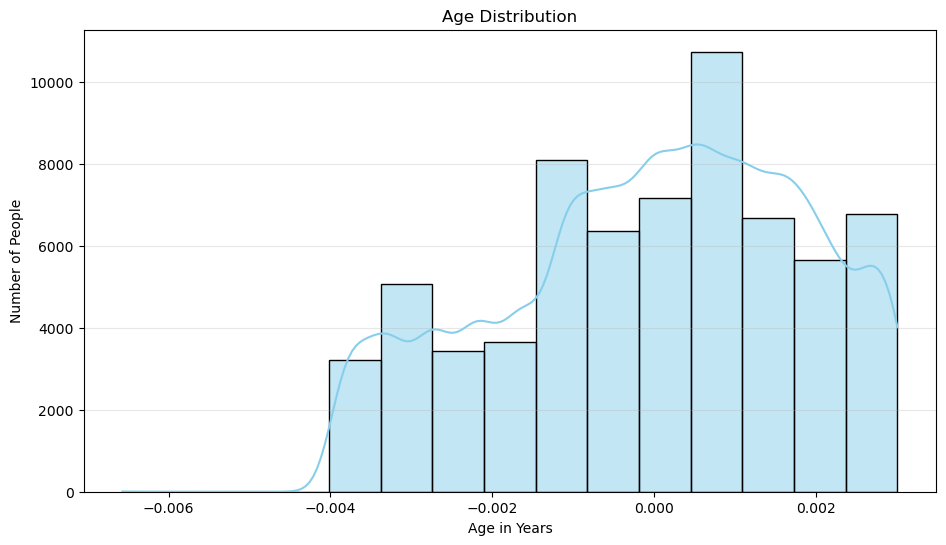

Real Age Statistics:
count    66929.0
mean        -0.0
std          0.0
min         -0.0
25%         -0.0
50%          0.0
75%          0.0
max          0.0
Name: age_years, dtype: float64


In [41]:
# 1. Create real age_with_years (in years) before any Scaling
df['age_years'] = df['age_with_years'] / 365.25

# 2. Distribution of real age (Simple Histogram)
plt.figure(figsize=(11, 6))
sns.histplot(df['age_years'], bins=15, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age in Years')
plt.ylabel('Number of People')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Print statistics of real age to verify
print("Real Age Statistics:")
print(df['age_years'].describe().round(1))

SUPER VIESD

In [42]:


from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

from xgboost import XGBClassifier

In [ ]:
# Target
y = df['cardio']
X = df.drop(['cardio'], axis=1)

In [44]:
from sklearn.model_selection import train_test_split

X_train , X_test ,Y_train ,Y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [45]:
# Optional scaling for Logistic Regression
stand = StandardScaler()
X_train = stand.fit_transform(X_train)
X_test = stand.transform(X_test)
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df.loc[:, ['bmi']] = scaler.fit_transform(df[['bmi']])

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
model = LogisticRegression()
model.fit(X_train , Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
y_pred = model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score , confusion_matrix , recall_score , precision_score , f1_score , roc_curve , roc_auc_score

In [50]:
conf= confusion_matrix(Y_test , y_pred)

In [51]:
sns.heatmap(conf , annot = True , cmap="Blues")

<Axes: >

In [52]:
f1_score(Y_test , y_pred)

0.7103868364844553

In [53]:
precision_score(Y_test , y_pred)

0.7455994686150781

In [54]:
recall_score(Y_test , y_pred)

0.6783502039583018

In [55]:
accuracy_score(Y_test , y_pred)

0.7265053040490064

In [56]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.77      0.74      6767
           1       0.75      0.68      0.71      6619

    accuracy                           0.73     13386
   macro avg       0.73      0.73      0.73     13386
weighted avg       0.73      0.73      0.73     13386



logistic

In [57]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [58]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Optional tuning
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1
)

# Convert 'bmi_category' to int to be compatible with XGBoost
X['bmi_category'] = X['bmi_category'].astype(int)
# #  dont delete it pls mohamed ashraaaaaaaf
grid_xgb.fit(X, y)

best_xgb = grid_xgb.best_estimator_

# CV AUC
xgb_auc = cross_val_score(best_xgb, X, y, cv=skf, scoring='roc_auc')
print("XGBoost AUC:", xgb_auc.mean())

XGBoost AUC: 0.800451340604717


Random Forest AUC: 0.7977144119719746


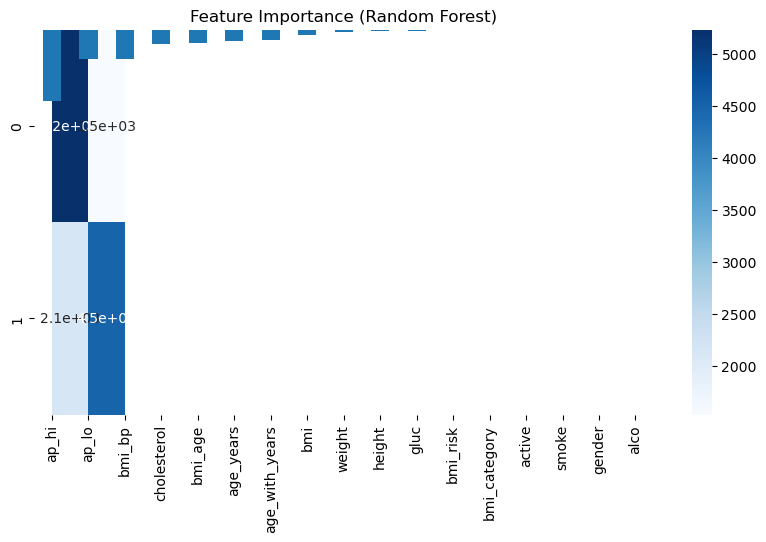

In [59]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf_auc = cross_val_score(rf, X, y, cv=skf, scoring='roc_auc')
print("Random Forest AUC:", rf_auc.mean())

# Fit for feature importance
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance (Random Forest)")
plt.show()

Logistic Regression AUC: 0.7901369407535117


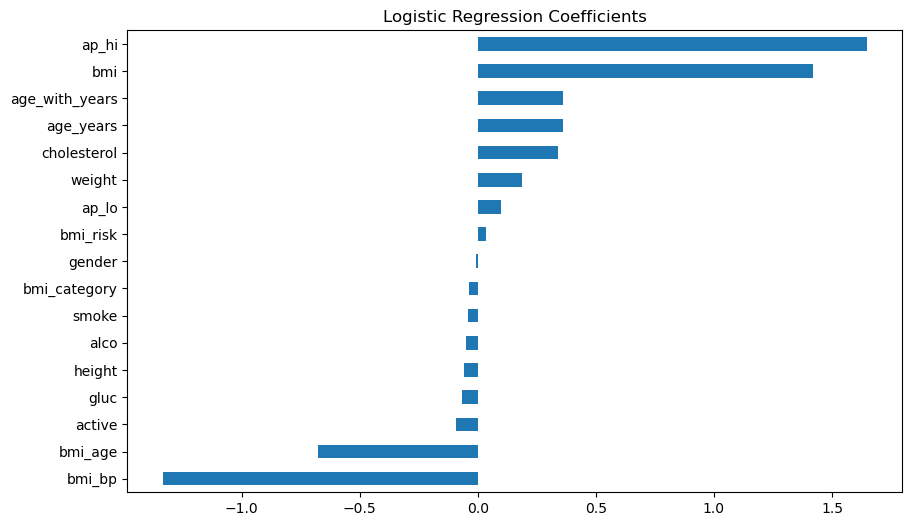

In [60]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        penalty='l2',   # regularization
        C=1.0,
        solver='liblinear',
        max_iter=1000
    ))
])

lr_auc = cross_val_score(lr_pipeline, X, y, cv=skf, scoring='roc_auc')
print("Logistic Regression AUC:", lr_auc.mean())

# Fit for interpretability
lr_pipeline.fit(X, y)

coeffs = pd.Series(
    lr_pipeline.named_steps['lr'].coef_[0],
    index=X.columns
)

coeffs.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Logistic Regression Coefficients")
plt.show()

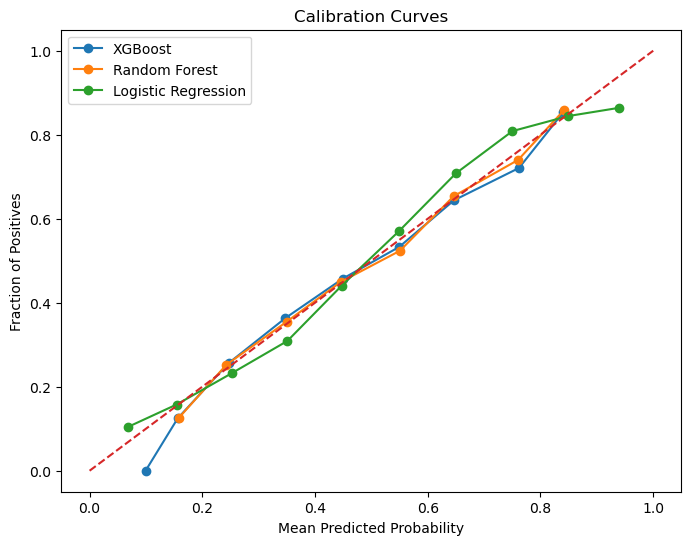

In [61]:
from sklearn.calibration import CalibratedClassifierCV

models = {
    "XGBoost": best_xgb,
    "Random Forest": rf,
    "Logistic Regression": lr_pipeline
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    calibrated = CalibratedClassifierCV(model, cv=skf)
    calibrated.fit(X, y)

    prob_pos = calibrated.predict_proba(X)[:, 1]
    frac_pos, mean_pred = calibration_curve(y, prob_pos, n_bins=10)

    plt.plot(mean_pred, frac_pos, marker='o', label=name)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curves")
plt.legend()
plt.show()

In [62]:
print("=== Final AUC Scores ===")
print(f"XGBoost: {xgb_auc.mean():.4f}")
print(f"Random Forest: {rf_auc.mean():.4f}")
print(f"Logistic Regression: {lr_auc.mean():.4f}")

=== Final AUC Scores ===
XGBoost: 0.8005
Random Forest: 0.7977
Logistic Regression: 0.7901


In [63]:
scale_pos_weight = len(y[y==0]) / len(y[y==1])

In [64]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', best_xgb)
    ],
    final_estimator=LogisticRegression()
)

CHECK OVER FITTING

In [65]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    lr_pipeline, X, y,
    cv=skf,
    scoring='roc_auc',
    return_train_score=True
)

print("Train AUC:", scores['train_score'].mean())
print("Test AUC:", scores['test_score'].mean())

Train AUC: 0.7903360074620991
Test AUC: 0.7901369407535117


In [66]:
models = {
    "XGBoost": best_xgb,
    "Random Forest": rf,
    "Logistic Regression": lr_pipeline
}

In [67]:
for name, model in models.items():
    scores = cross_validate(
        model, X, y,
        cv=skf,
        scoring='roc_auc',
        return_train_score=True
    )

    print(f"{name}")
    print("Train:", scores['train_score'].mean())
    print("Test:", scores['test_score'].mean())
    print("-"*30)

XGBoost
Train: 0.811007257219995
Test: 0.800451340604717
------------------------------
Random Forest
Train: 0.8138769994110161
Test: 0.7977144119719746
------------------------------
Logistic Regression
Train: 0.7903360074620991
Test: 0.7901369407535117
------------------------------


Unsupervised

In [68]:

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


features = ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
X = df[features]


scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42, n_init=10)
df['cluster_id'] = kmeans.fit_predict(X_scaled)

cluster_analysis = df.groupby('cluster_id')[features].mean()


print(cluster_analysis)

              gender    height    weight       ap_hi      ap_lo  cholesterol  \
cluster_id                                                                     
0           0.251300 -0.208881  0.304463  130.253433  82.832689     2.805626   
1           0.762699  0.659491  0.612246  122.645975  79.917957     1.125622   
2           0.157770 -0.311104 -0.281273  120.929891  80.241056     1.083698   
3           0.575954  0.330617  1.084144  155.620230  96.563355     1.651188   
4           0.229749 -0.355730 -0.016962  143.868318  90.753598     1.205798   
5           0.222329 -0.236238 -0.286189  109.252011  67.419092     1.170433   

                gluc     smoke      alco    active  
cluster_id                                          
0           2.078390  0.067191  0.051193  0.810292  
1           1.115673  0.185105  0.092132  0.797310  
2           1.076183  0.033664  0.026407  0.798219  
3           1.300036  0.151728  0.099712  0.801476  
4           1.099301  0.057669  0.040810 

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19088\1948829246.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster_id'] = kmeans.fit_predict(X_scaled)


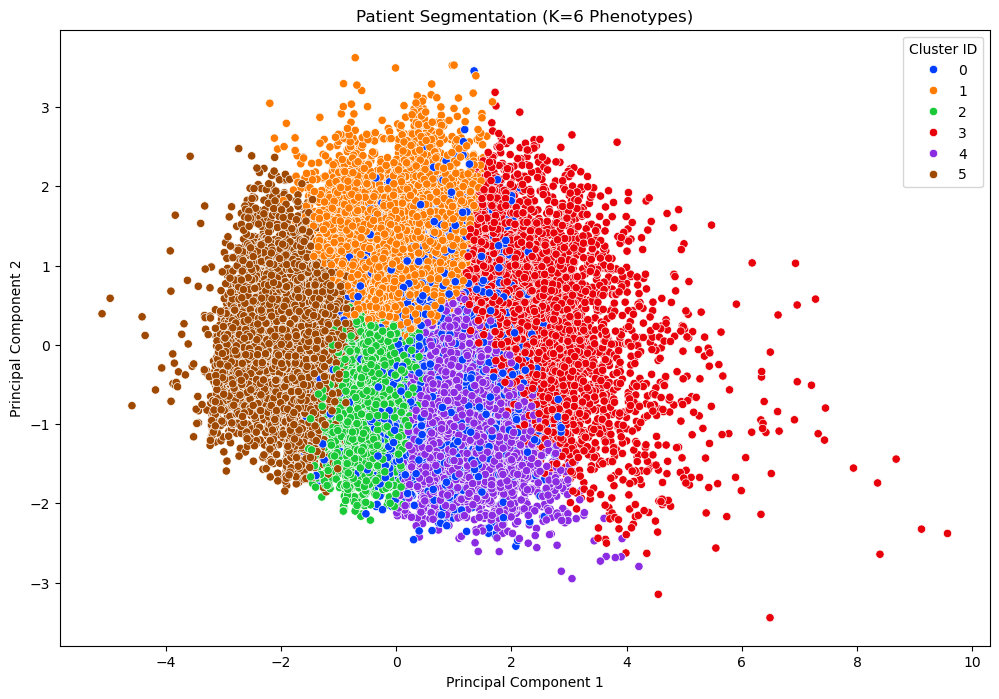

In [69]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster_id'], palette='bright')
plt.title('Patient Segmentation (K=6 Phenotypes)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster ID')
plt.show()

In [70]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=10) 
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)


outliers = df[df['dbscan_cluster'] == -1]

print(f"Unique Risk Profiles (Outliers): {len(outliers)}")

Unique Risk Profiles (Outliers): 112


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19088\4243666392.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)


In [71]:

outlier_analysis = outliers[features].mean()
normal_analysis = df[df['dbscan_cluster'] != -1][features].mean()

comparison = pd.DataFrame({
    'Normal Patients': normal_analysis,
    'Unique Risk Profiles (Outliers)': outlier_analysis
})

print(comparison)

             Normal Patients  Unique Risk Profiles (Outliers)
gender              0.352231                         0.517857
height             -0.034580                         0.195617
weight              0.124556                         0.938603
ap_hi             126.648622                       176.660714
ap_lo              81.314650                        99.294643
cholesterol         1.362962                         1.991071
gluc                1.223985                         1.669643
smoke               0.087957                         0.312500
alco                0.053145                         0.276786
active              0.803358                         0.723214


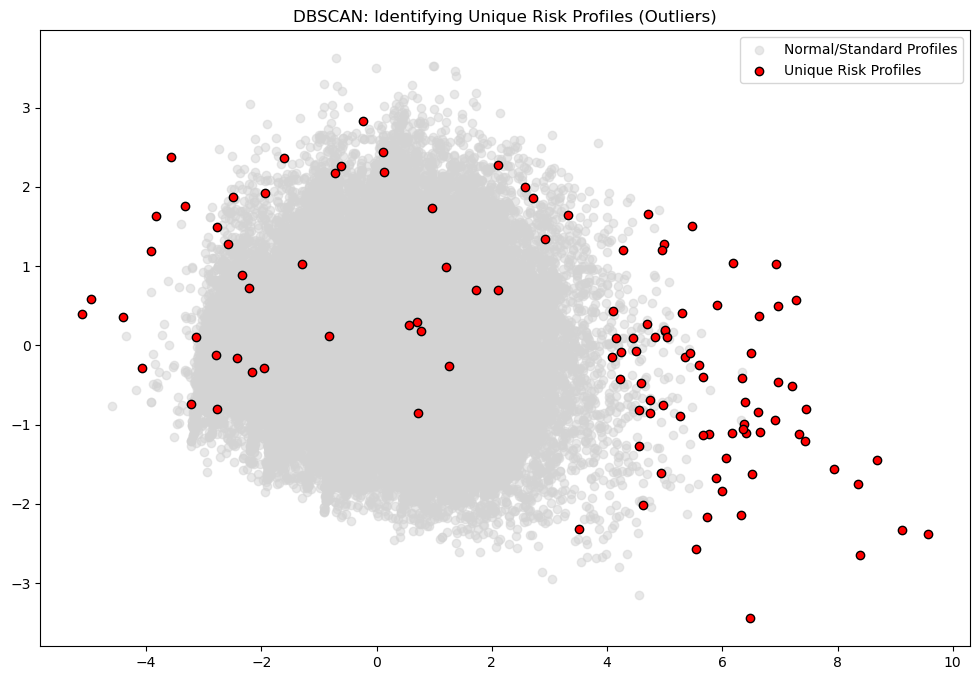

In [72]:
plt.figure(figsize=(12, 8))

plt.scatter(X_pca[df['dbscan_cluster'] != -1, 0], 
            X_pca[df['dbscan_cluster'] != -1, 1], 
            c='lightgrey', label='Normal/Standard Profiles', alpha=0.5)


plt.scatter(X_pca[df['dbscan_cluster'] == -1, 0], 
            X_pca[df['dbscan_cluster'] == -1, 1], 
            c='red', label='Unique Risk Profiles', edgecolors='black')

plt.title('DBSCAN: Identifying Unique Risk Profiles (Outliers)')
plt.legend()
plt.show()

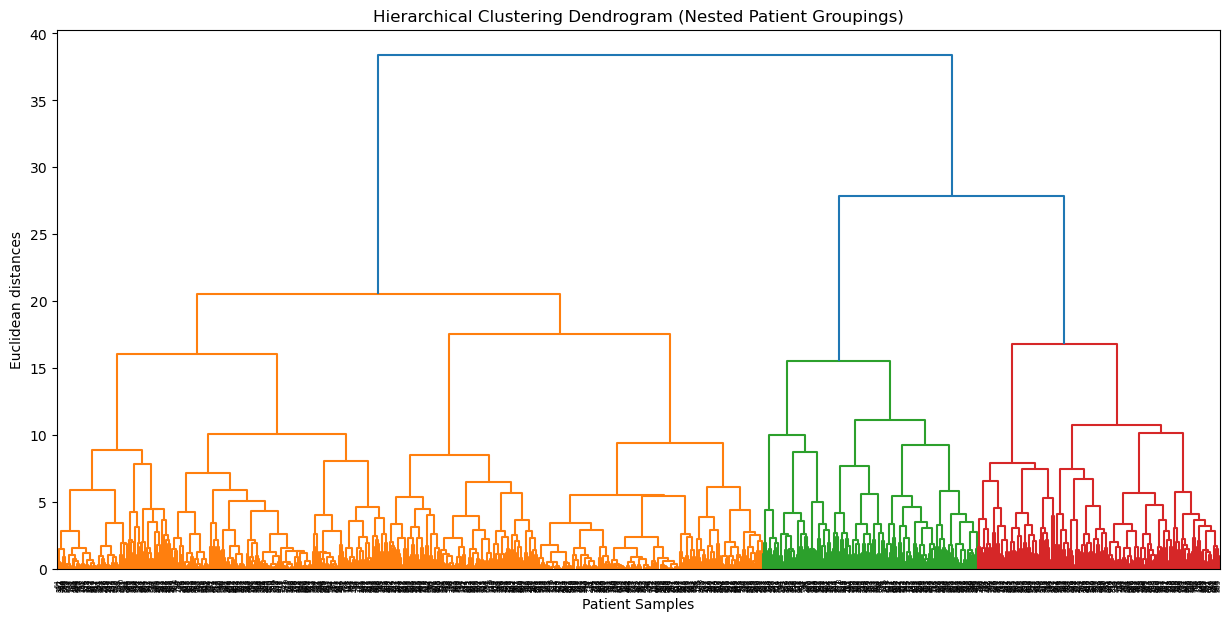

Dendrogram generated. This tree shows how patients are nested into sub-groups.

--- Hierarchical Cluster Profiles (Sample) ---
                        gender    height    weight       ap_hi      ap_lo  \
hierarchical_cluster                                                        
0                     0.109034 -0.250071 -0.305479  116.246106  75.551402   
1                     0.389423  0.014423  0.523049  150.798077  92.427885   
2                     0.291892 -0.112531  0.188235  129.302703  82.286486   
3                     0.678322  0.235219  0.389284  122.870629  80.241259   

                      cholesterol      gluc     smoke      alco    active  
hierarchical_cluster                                                       
0                        1.052960  1.046729  0.028037  0.018692  0.760125  
1                        1.375000  1.173077  0.076923  0.033654  0.836538  
2                        2.497297  1.789189  0.091892  0.021622  0.816216  
3                        1.097

In [73]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt


df_sample = df.sample(n=1000, random_state=42)
X_sample_scaled = scaler.transform(df_sample[features])

# Step 1: Create the Dendrogram to visualize nested groupings
plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram (Nested Patient Groupings)')
plt.xlabel('Patient Samples')
plt.ylabel('Euclidean distances')

# Using 'ward' linkage to minimize variance within clusters
dendrogram = sch.dendrogram(sch.linkage(X_sample_scaled, method='ward'))
plt.show()

print("Dendrogram generated. This tree shows how patients are nested into sub-groups.")

# Step 2: Apply Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering


hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df_sample['hierarchical_cluster'] = hc.fit_predict(X_sample_scaled)


# Step 3: Analyze the hierarchy
print("\n--- Hierarchical Cluster Profiles (Sample) ---")
print(df_sample.groupby('hierarchical_cluster')[features].mean())

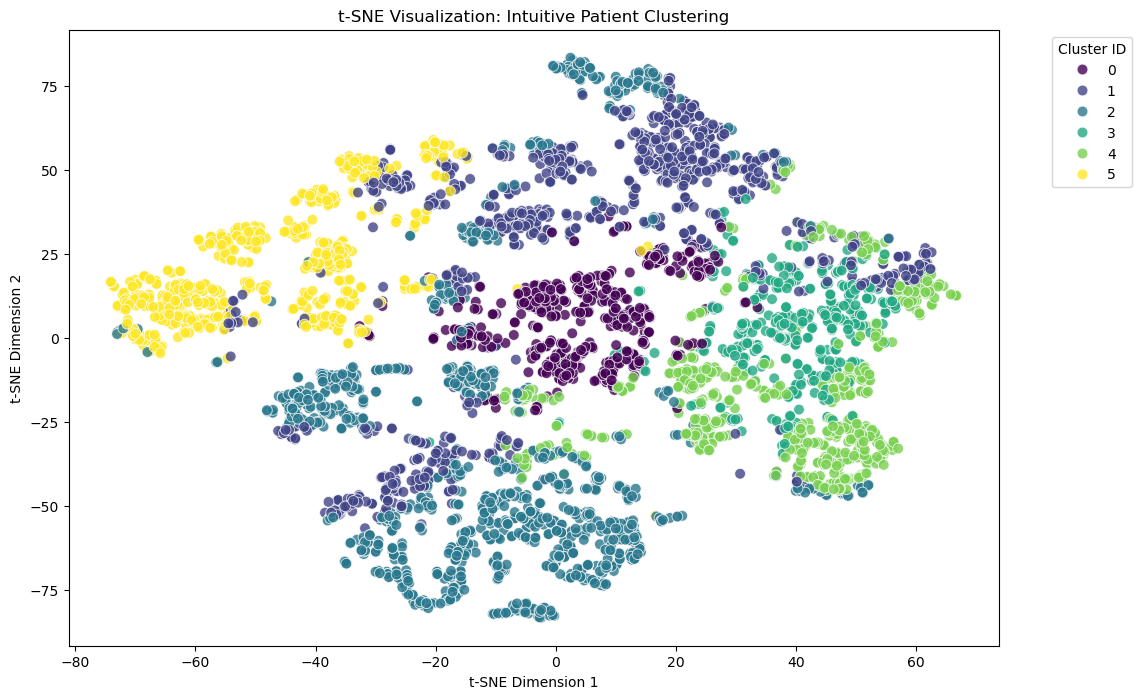

t-SNE visualization generated. The 'learning_rate' was set to 'auto' for best results.


In [74]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns


df_tsne_sample = df.sample(n=5000, random_state=42)
X_tsne_scaled = scaler.transform(df_tsne_sample[features])

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_tsne_scaled)


tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['cluster'] = df_tsne_sample['cluster_id'].values

# visualization
plt.figure(figsize=(12, 8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='cluster', data=tsne_df, palette='viridis', s=60, alpha=0.8)

plt.title('t-SNE Visualization: Intuitive Patient Clustering')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("t-SNE visualization generated. The 'learning_rate' was set to 'auto' for best results.")

--- Final Clinical Profiles per Cluster ---
           age_with_years       gender       height       weight        \
                     mean   std   mean   std   mean   std   mean   std   
cluster_id                                                               
0                    0.25  0.59   0.25  0.43  -0.21  0.64   0.30  0.77   
1                   -0.10  0.69   0.76  0.43   0.66  0.53   0.61  0.68   
2                   -0.04  0.66   0.16  0.36  -0.31  0.51  -0.28  0.50   
3                    0.11  0.64   0.58  0.49   0.33  0.69   1.08  0.74   
4                    0.13  0.63   0.23  0.42  -0.36  0.57  -0.02  0.59   
5                   -0.26  0.70   0.22  0.42  -0.24  0.59  -0.29  0.58   

             ap_hi         ... cholesterol        gluc       smoke        \
              mean    std  ...        mean   std  mean   std  mean   std   
cluster_id                 ...                                             
0           130.25  11.93  ...        2.81  0.43  2.08  0.91 

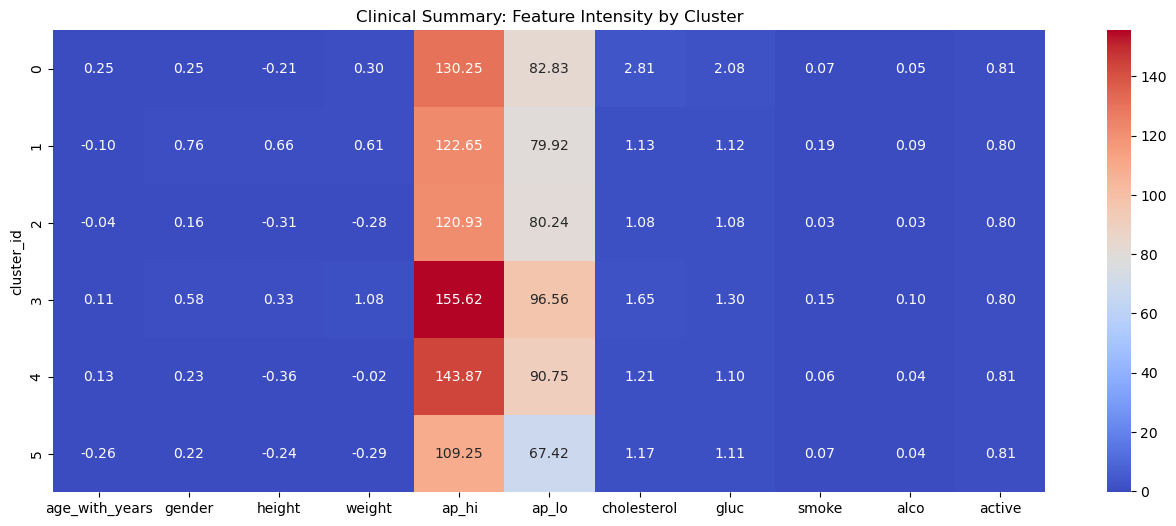


Analysis complete. You can now present these profiles as your final strategy.


In [75]:

final_features = ['age_with_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


cluster_summary = df.groupby('cluster_id')[final_features].agg(['mean', 'std']).round(2)

print("--- Final Clinical Profiles per Cluster ---")
print(cluster_summary)


cvd_risk = (df.groupby('cluster_id')['cardio'].mean() * 100).round(2)
print("\n--- Cardiovascular Disease (CVD) Prevalence per Cluster (%) ---")
print(cvd_risk)


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
sns.heatmap(df.groupby('cluster_id')[final_features].mean(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Clinical Summary: Feature Intensity by Cluster')
plt.show()

print("\nAnalysis complete. You can now present these profiles as your final strategy.")

In [76]:
import joblib
from xgboost import XGBClassifier


features = ['age_with_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
X = df[features]
y = df['cardio']


final_model = XGBClassifier(n_estimators=100, random_state=42)
final_model.fit(X, y)


joblib.dump(final_model, 'risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl') 


df.to_csv('customer_data.csv', index=False)

print("All resources (Model, Scaler, Data) saved successfully!")

All resources (Model, Scaler, Data) saved successfully!


Streamlit

In [77]:
import streamlit as st
import pandas as pd
import joblib
import numpy as np


@st.cache_resource
def load_resources():
    # Loading the names we just saved
    model = joblib.load('risk_model.pkl')
    scaler = joblib.load('scaler.pkl')
    return model, scaler

@st.cache_data
def load_data():
    # Loading the 70k records
    return pd.read_csv('customer_data.csv')

model, scaler = load_resources()
df = load_data()

# Now the rest of the code for Lookup and Scoring...

2026-06-25 14:02:30.190 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-25 14:02:30.192 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:30.687 
  command:

    streamlit run C:\Users\Administrator\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-25 14:02:30.688 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:30.690 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:30.691 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:30.708 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:30.70

In [78]:

st.divider()
st.header("Interactive Segment Explorer")
st.markdown("Filter customers by demographics and health metrics to analyze specific segments.")

# 1. Layout for Filters
col_f1, col_f2, col_f3 = st.columns(3)

with col_f1:
    # Filter by Age (using your preprocessed column)
    age_range = st.slider("Select Age Range", 
                          int(df['age_with_years'].min()), 
                          int(df['age_with_years'].max()), 
                          (30, 60))

with col_f2:
    # Filter by Gender
    gender_filter = st.multiselect("Select Gender", 
                                   options=[1, 2], 
                                   default=[1, 2],
                                   format_func=lambda x: "Female" if x==1 else "Male")

with col_f3:
    # Filter by Cholesterol Level
    chol_filter = st.multiselect("Cholesterol Level", 
                                 options=[1, 2, 3], 
                                 default=[1, 2, 3])

# 2. Applying Filters to the Dataframe
filtered_df = df[
    (df['age_with_years'] >= age_range[0]) & 
    (df['age_with_years'] <= age_range[1]) & 
    (df['gender'].isin(gender_filter)) & 
    (df['cholesterol'].isin(chol_filter))
]

# 3. Displaying Segment Metrics
st.subheader(f"Results for this Segment ({len(filtered_df):,} customers)")

m1, m2, m3 = st.columns(3)
with m1:
    avg_weight = filtered_df['weight'].mean()
    st.metric("Avg. Weight", f"{avg_weight:.1f} kg")
with m2:
    # Prevalence of CVD in this specific segment
    cvd_rate = (filtered_df['cardio'].mean() * 100)
    st.metric("CVD Prevalence", f"{cvd_rate:.1f}%")
with m3:
    avg_active = (filtered_df['active'].mean() * 100)
    st.metric("Active Lifestyle", f"{avg_active:.1f}%")

# 4. Segment Visualization
st.write("### Distribution of Clusters in this Segment")
# Displaying the K-Means clusters distribution for this filtered segment
if 'cluster_id' in filtered_df.columns:
    cluster_counts = filtered_df['cluster_id'].value_counts().sort_index()
    st.bar_chart(cluster_counts)
    st.caption("This chart shows how many customers fall into each clinical phenotype within your filters.")
else:
    st.warning("Please run the Clustering step in your notebook to see Cluster IDs.")

2026-06-25 14:02:31.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.087 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.090 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.092 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.093 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.095 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.096 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

2026-06-25 14:02:31.111 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.112 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.113 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.115 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.117 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.118 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.120 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:31.121 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [79]:
# --- Requirement: Campaign Performance Simulator ---
st.divider()
st.header("Campaign Performance Simulator")
st.markdown("Estimate the potential ROI of targeting specific patient segments.")

# 1. Simulator Inputs
col_s1, col_s2 = st.columns(2)

with col_s1:
    st.subheader("Campaign Budgeting")
    total_budget = st.number_input("Total Marketing Budget ($)", min_value=1000, value=10000, step=500)
    cost_per_reach = st.slider("Cost per Contact ($)", 0.5, 5.0, 1.5)
    
with col_s2:
    st.subheader("Expected Conversion")
    # Conversion here means: Customer starts a prevention program
    expected_conv_rate = st.slider("Target Conversion Rate (%)", 1.0, 20.0, 5.0) / 100
    prevention_program_value = st.number_input("Value per Program Enrolment ($)", min_value=50, value=250)

# 2. Simulation Logic
# We use the filtered_df from the previous step (Explorer) to target specific people
target_audience_size = len(filtered_df)
potential_reach = int(total_budget / cost_per_reach)

# Limit reach to target audience size
actual_reach = min(potential_reach, target_audience_size)
expected_conversions = int(actual_reach * expected_conv_rate)
total_revenue = expected_conversions * prevention_program_value
roi = ((total_revenue - total_budget) / total_budget) * 100

# 3. Displaying Results
st.write(f"### Simulation Results for Selected Segment")

r1, r2, r3, r4 = st.columns(4)
with r1:
    st.metric("Potential Reach", f"{actual_reach:,}")
with r2:
    st.metric("Expected Enrolments", f"{expected_conversions:,}")
with r3:
    st.metric("Projected Revenue", f"${total_revenue:,.0f}")
with r4:
    # Color coding for ROI
    st.metric("Projected ROI", f"{roi:.1f}%", delta=f"{roi:.1f}%", delta_color="normal")

# 4. Strategic Recommendation based on Cluster Risk
st.info("trategic Insight:** This segment has a CVD prevalence of " + 
        f"{filtered_df['cardio'].mean()*100:.1f}%. " +
        "High-risk segments usually have higher conversion rates for health programs.")

# Plotting the ROI Projection
labels = ['Budget', 'Expected Revenue']
values = [total_budget, total_revenue]
fig_sim, ax_sim = plt.subplots(figsize=(6, 4))
sns.barplot(x=labels, y=values, palette=['#FF9999','#66b3ff'], ax=ax_sim)
plt.title("Cost vs. Projected Revenue")
st.pyplot(fig_sim)

2026-06-25 14:02:32.707 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:32.709 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:32.710 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:32.712 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:32.714 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:32.715 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:32.717 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:32.719 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [80]:
# --- Requirement: Customer Lifetime Value (CLV) Forecasting ---
st.divider()
st.header("Customer Lifetime Value (CLV) Projection")
st.markdown("Forecasting the long-term economic value of patient prevention programs.")

# 1. CLV Logic setup
# We define CLV as: (Cost Saved by Prevention * Probability of staying healthy)
# Patients in low-risk clusters have higher "Retention" in health programs.

st.subheader("Financial Assumptions")
c1, c2 = st.columns(2)
with c1:
    annual_treatment_cost = st.number_input("Avg. Annual Treatment Cost ($)", value=5000)
with c2:
    years_projection = st.slider("Projection Period (Years)", 1, 10, 5)

# 2. Calculating CLV per Cluster
# We assume that preventing CVD in a high-risk patient saves the 'annual_treatment_cost'
def calculate_clv(row):
    # Higher risk (cardio=1) means higher potential saving if prevented
    base_value = annual_treatment_cost * years_projection
    # Probability of health improvement (Simplified logic for the simulation)
    prob_improvement = 0.8 if row['active'] == 1 else 0.4
    return base_value * prob_improvement

# Apply to filtered data
filtered_df['estimated_clv'] = filtered_df.apply(calculate_clv, axis=1)

# 3. Displaying CLV Insights
cv1, cv2 = st.columns(2)

with cv1:
    st.write("### Total Projected Value")
    total_clv = filtered_df['estimated_clv'].sum()
    st.metric("Total Segment CLV", f"${total_clv:,.0f}")
    st.caption("Total cost savings projected for this patient segment.")

with cv2:
    st.write("### CLV by Clinical Cluster")
    clv_by_cluster = filtered_df.groupby('cluster_id')['estimated_clv'].mean()
    st.bar_chart(clv_by_cluster)

# 4. Strategic Recommendation
st.success(f"Proactive Strategy: \n" 
           f"Targeting this segment for preventive care can potentially save "
           f"**${total_clv/len(filtered_df):,.0f}** per patient over {years_projection} years.")

2026-06-25 14:02:33.138 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.140 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.141 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.142 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.143 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.145 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.146 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.148 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [81]:
# --- Requirement: Export Functionality ---
st.divider()
st.header("Export Marketing Lists")
st.markdown("Download the filtered customer segment for your marketing campaigns.")

# 1. Prepare the Export Data
# We select the most important columns for the marketing team
export_columns = ['age_with_years', 'gender', 'cholesterol', 'active', 'cardio']
if 'cluster_id' in filtered_df.columns:
    export_columns.append('cluster_id')

export_df = filtered_df[export_columns].copy()

# 2. Add a 'Priority' column based on Risk (Cardio) and Activity
def assign_priority(row):
    if row['cardio'] == 1 and row['active'] == 0:
        return 'Critical'
    elif row['cardio'] == 1:
        return 'High'
    else:
        return 'Standard'

export_df['Campaign_Priority'] = export_df.apply(assign_priority, axis=1)

# 3. Create the Download Button
# Converting dataframe to CSV
csv = export_df.to_csv(index=False).encode('utf-8')

st.write(f"Total customers in this export: **{len(export_df):,}**")

st.download_button(
    label="Download Segment CSV",
    data=csv,
    file_name='marketing_target_list.csv',
    mime='text/csv',
    help="Click to download the filtered list for CRM or Email Marketing tools."
)

# 4. Preview of the Export List
st.subheader("Preview of Export Data")
st.dataframe(export_df.head(10))

print("Export functionality is live. Marketing teams can now download targeted lists.")

2026-06-25 14:02:33.241 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.242 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.243 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.244 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.246 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.247 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.248 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 14:02:33.249 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Export functionality is live. Marketing teams can now download targeted lists.
